<a href="https://colab.research.google.com/github/ag-coder05/Data_Science_Intership_Assignments/blob/main/Assignment4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df= pd.read_csv('Titanic-Dataset.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
#Filling null values of age depending on combined mean of particular sex and pclass
df['Age'] = df['Age'].fillna(df.groupby(['Sex', 'Pclass'])['Age'].transform('mean'))
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:

# 1. Survival Propability Percentage by Gender
print(df.groupby('Sex')['Survived'].mean()*100)
# 2. Survival Propability Percentage by Class
print(df.groupby('Pclass')['Survived'].mean()*100)
# 3. Survival Propability Percentage by Age Group (Children vs Adults)
df['IsChild'] = df['Age'] < 18
print(df.groupby('IsChild')['Survived'].mean()*100)

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64
IsChild
False    36.118252
True     53.982301
Name: Survived, dtype: float64


Above analysis shows,
By Sex:
~74% of total females survived, while ~19% of total men survived.
By Class:
~63% of 1st Class passengers survived, ~47% of 2nd Class passengers survived and ~24% of 3rd Class passengers survived.
By Age (Children vs. Adults):
~54% of Children(under 18) survived while ~36% of Adults survived.


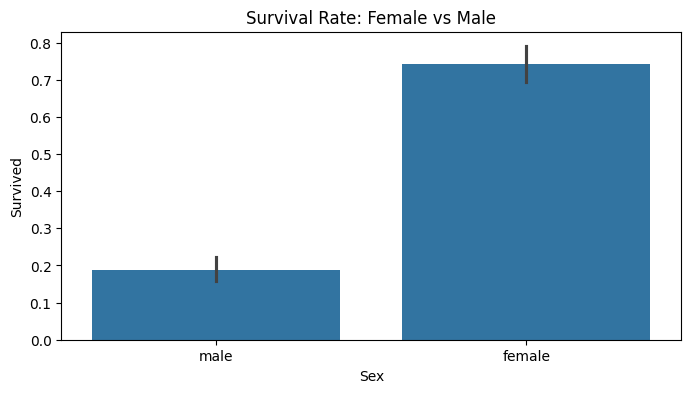

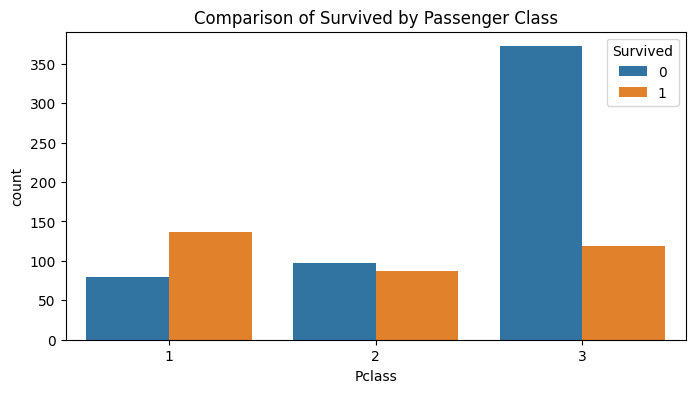

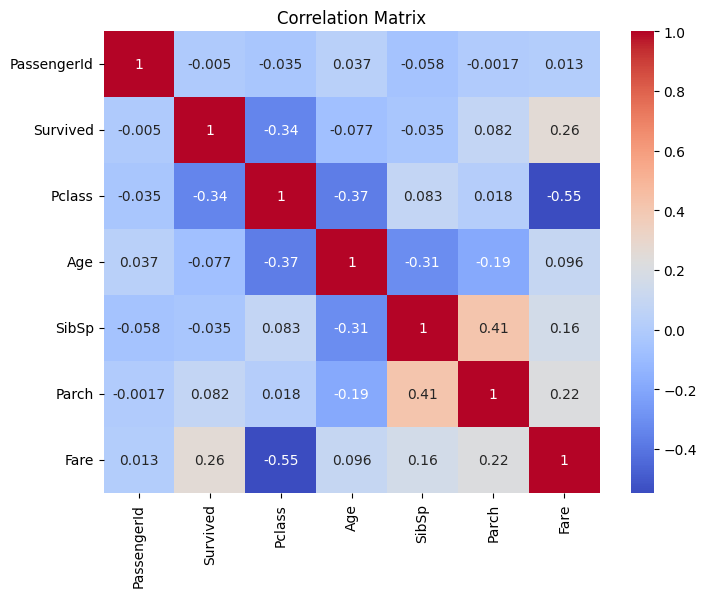

In [ ]:
#Relevent plots
#Gender vs Survival
plt.figure(figsize=(8,4))
sns.barplot(x='Sex', y='Survived', data=df)
plt.title('Survival Rate: Female vs Male')
plt.show()
#Class vs Survival
plt.figure(figsize=(8,4))
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title('Comparison of Survived by Passenger Class')
plt.show()
#Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

From above plots we can see
1.Male survival low compared to female
2.Even though less people were from 1st class, higher percentage survived, while more people where in 3rd class, but less percentage survived
3.Heatmap shows numeric column correlation